# Spam Detection using Decision Trees
---
This notebook implements a complete Decision Tree-based spam classifier on the UCI Spambase dataset.
It covers three experimental scenarios:
- **Case A**: With vs. Without Feature Normalization
- **Case B**: Overfitting demonstration and remediation (pruning)
- **Case C**: Handling class imbalance (bias study)


## 1. Imports and Configuration

In [243]:

import zipfile
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import ListedColormap

# ── Scikit-learn: Pre-processing ─────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# ── Scikit-learn: Modelling ──────────────────────────────────────────────────
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
    plot_tree
)

# ── Scikit-learn: Evaluation ─────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

# ── Global Plot Style ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RANDOM_STATE = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Data Loading
We extract `spambase.data` and `spambase.names` from the ZIP archive and
dynamically parse column names from the `.names` file.

In [244]:
# ── 2.1  Extract ZIP ─────────────────────────────────────────────────────────
ZIP_PATH = 'spambase/'   # folder already extracted alongside notebook
DATA_FILE = os.path.join(ZIP_PATH, 'spambase.data')
NAME_FILE = os.path.join(ZIP_PATH, 'spambase.names')

# ── 2.2  Parse column names from .names file ─────────────────────────────────
def parse_column_names(names_path: str) -> list:
    """
    Read the UCI .names file and extract feature names dynamically.
    Lines that define an attribute follow the pattern: 'attribute_name: continuous.'
    Comment lines begin with '|'.
    """
    columns = []
    with open(names_path, 'r') as f:
        for line in f:
            line = line.strip()
            # Skip comments and the class definition line
            if line.startswith('|') or not line or line.startswith('1,'):
                continue
            # Match 'attribute_name: continuous.' pattern
            match = re.match(r'^(.+?):\s+continuous\.', line)
            if match:
                columns.append(match.group(1))
    return columns

feature_names = parse_column_names(NAME_FILE)
# The last column in .data is the class label
all_columns   = feature_names + ['spam']

print(f'Number of features parsed : {len(feature_names)}')
print(f'Total columns (incl. label): {len(all_columns)}')
print('\nFirst 5 feature names:', feature_names[:5])
print('Last  5 feature names:', feature_names[-5:])

Number of features parsed : 57
Total columns (incl. label): 58

First 5 feature names: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our']
Last  5 feature names: ['char_freq_$', 'char_freq_#', 'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total']


In [245]:
# ── 2.3  Load data into DataFrame ────────────────────────────────────────────
df = pd.read_csv(DATA_FILE, header=None, names=all_columns)

print('Dataset shape:', df.shape)
print('\nClass distribution:')
class_counts = df['spam'].value_counts().sort_index()
print(class_counts)
print(f'\nSpam  : {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)')
print(f'Ham   : {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)')
df.head()

Dataset shape: (4601, 58)

Class distribution:
spam
0    2788
1    1813
Name: count, dtype: int64

Spam  : 1813 (39.4%)
Ham   : 2788 (60.6%)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [246]:
# ── 2.4  Basic statistics ────────────────────────────────────────────────────
print('Missing values:', df.isnull().sum().sum())
print('\nDescriptive Statistics (first 5 features):')
df[feature_names[:5]].describe().round(3)

Missing values: 0

Descriptive Statistics (first 5 features):


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our
count,4601.000,4601.000,4601.000,4601.000,4601.000
mean,0.105,0.213,0.281,0.065,0.312
std,0.305,1.291,0.504,1.395,0.673
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.420,0.000,0.380
max,4.540,14.280,5.100,42.810,10.000


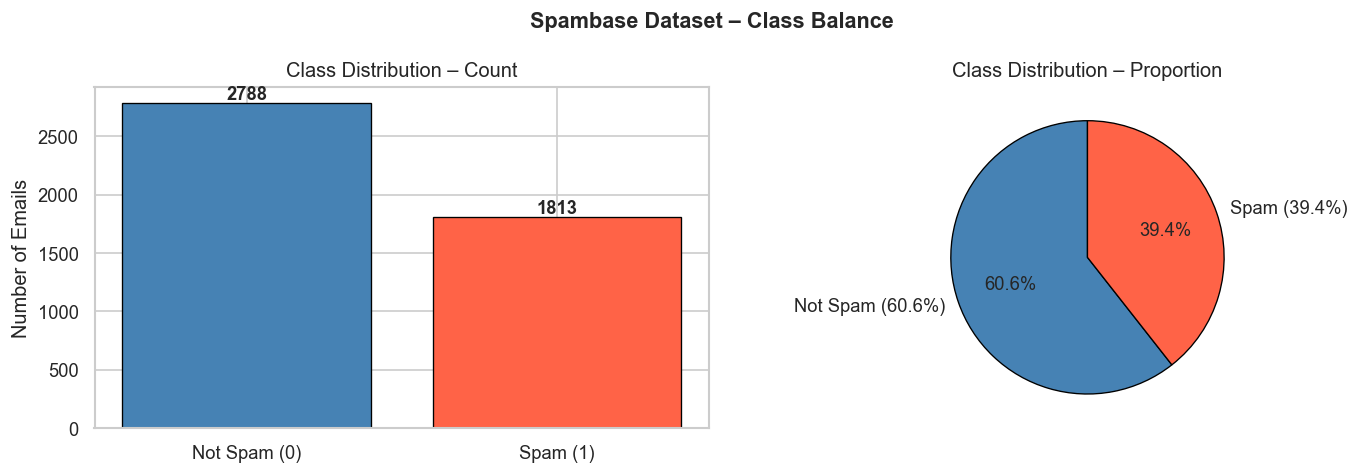

In [247]:
# ── 2.5  Class distribution bar chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Not Spam (0)', 'Spam (1)'],
            [class_counts[0], class_counts[1]],
            color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution – Count')
axes[0].set_ylabel('Number of Emails')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Not Spam (60.6%)', 'Spam (39.4%)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Class Distribution – Proportion')

plt.suptitle('Spambase Dataset – Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. Data Splitting
We split the dataset into **Training (60%)**, **Validation (20%)**, and **Test (20%)** sets.
Stratified splitting ensures each partition preserves the original class ratio.

In [248]:
X = df[feature_names].values
y = df['spam'].values

# Step 1: Split off 20% as Test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Step 2: From remaining 80%, split 25% as Validation → 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

print('Split Summary')
print('─' * 40)
print(f'Training   : {X_train.shape[0]:>5} samples  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation : {X_val.shape[0]:>5} samples  ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test       : {X_test.shape[0]:>5} samples  ({X_test.shape[0]/len(X)*100:.1f}%)')
print('─' * 40)
print(f'Total      : {len(X):>5} samples')

Split Summary
────────────────────────────────────────
Training   :  2760 samples  (60.0%)
Validation :   920 samples  (20.0%)
Test       :   921 samples  (20.0%)
────────────────────────────────────────
Total      :  4601 samples


---
## 4. Helper Functions
Reusable utilities for evaluation, confusion matrix plotting, and reporting.

In [249]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, X_te, y_te, title='Model'):
    """
    Trains (fits) the model and prints accuracy on all three splits,
    a confusion matrix, and a classification report.

    Returns: (train_acc, val_acc, test_acc, y_pred_test)
    """
    model.fit(X_tr, y_tr)

    train_acc = accuracy_score(y_tr,  model.predict(X_tr))
    val_acc   = accuracy_score(y_v,   model.predict(X_v))
    test_acc  = accuracy_score(y_te,  model.predict(X_te))
    y_pred    = model.predict(X_te)

    print(f'\n{"═"*55}')
    print(f'  {title}')
    print(f'{"═"*55}')
    print(f'  Train Accuracy      : {train_acc*100:6.2f}%')
    print(f'  Validation Accuracy : {val_acc*100:6.2f}%')
    print(f'  Test  Accuracy      : {test_acc*100:6.2f}%')
    print(f'{"─"*55}')
    print('\nClassification Report (Test Set):') 
    print(classification_report(y_te, y_pred,
                                target_names=['Not Spam (0)', 'Spam (1)']))

    # Confusion Matrix
    cm  = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Spam', 'Spam'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix – {title}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

    return train_acc, val_acc, test_acc, y_pred


# Summary table for final comparison
results_summary = {}

---
## 5. Case A – Normalization Study
Decision Trees are theoretically invariant to feature scaling, but normalization can
affect numerical precision and training speed. We compare both scenarios.

### 5.1 – Without Normalization (Baseline)


═══════════════════════════════════════════════════════
  Case A-1 – No Normalization
═══════════════════════════════════════════════════════
  Train Accuracy      :  96.34%
  Validation Accuracy :  91.96%
  Test  Accuracy      :  91.31%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.91      0.94      0.93       558
    Spam (1)       0.91      0.87      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921



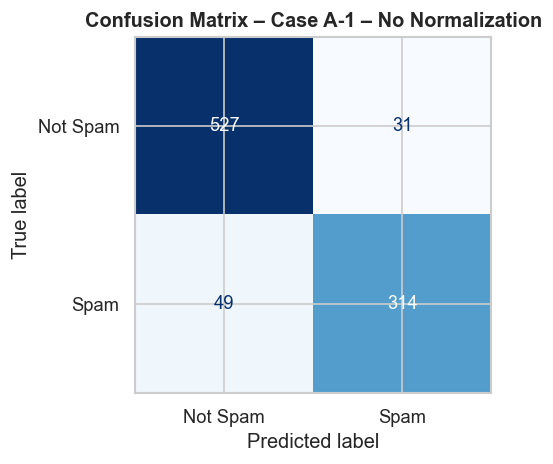

In [250]:
# ── Case A-1: No normalization ───────────────────────────────────────────────
dt_no_norm = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=RANDOM_STATE
)

tr_a1, v_a1, te_a1, _ = evaluate_model(
    dt_no_norm,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    title='Case A-1 – No Normalization'
)
results_summary['A1 – No Norm'] = {'Train': tr_a1, 'Val': v_a1, 'Test': te_a1}

### 5.2 – With MinMax Normalization


═══════════════════════════════════════════════════════
  Case A-2 – MinMax Normalization
═══════════════════════════════════════════════════════
  Train Accuracy      :  96.34%
  Validation Accuracy :  91.96%
  Test  Accuracy      :  91.31%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.91      0.94      0.93       558
    Spam (1)       0.91      0.87      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921



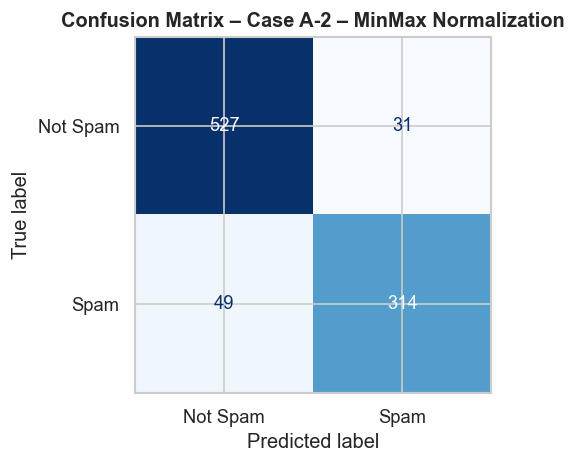

In [251]:
# ── Case A-2: MinMaxScaler normalization ─────────────────────────────────────
# IMPORTANT: Scaler is fit ONLY on training data to prevent data leakage
scaler = MinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)   # fit + transform on train
X_val_mm   = scaler.transform(X_val)          # transform only
X_test_mm  = scaler.transform(X_test)         # transform only

dt_minmax = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=RANDOM_STATE
)

tr_a2, v_a2, te_a2, _ = evaluate_model(
    dt_minmax,
    X_train_mm, y_train,
    X_val_mm,   y_val,
    X_test_mm,  y_test,
    title='Case A-2 – MinMax Normalization'
)
results_summary['A2 – MinMax'] = {'Train': tr_a2, 'Val': v_a2, 'Test': te_a2}

### 5.3 – With StandardScaler Normalization


═══════════════════════════════════════════════════════
  Case A-3 – Standard Normalization
═══════════════════════════════════════════════════════
  Train Accuracy      :  96.34%
  Validation Accuracy :  91.85%
  Test  Accuracy      :  91.31%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.91      0.94      0.93       558
    Spam (1)       0.91      0.87      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921



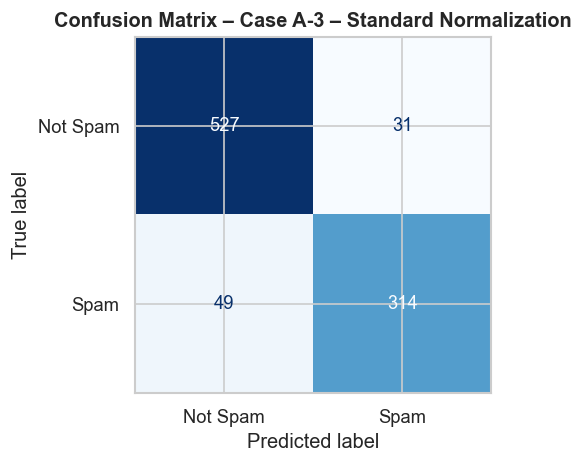

In [252]:
# ── Case A-3: StandardScaler normalization ───────────────────────────────────
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_val_std   = std_scaler.transform(X_val)
X_test_std  = std_scaler.transform(X_test)

dt_std = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=RANDOM_STATE
)

tr_a3, v_a3, te_a3, _ = evaluate_model(
    dt_std,
    X_train_std, y_train,
    X_val_std,   y_val,
    X_test_std,  y_test,
    title='Case A-3 – Standard Normalization'
)
results_summary['A3 – StdScaler'] = {'Train': tr_a3, 'Val': v_a3, 'Test': te_a3}

---
## 6. Case B – Overfitting Study
### 6.1 – Demonstrate Overfitting with an Unconstrained Tree


═══════════════════════════════════════════════════════
  Case B-1 – Overfit (No Depth Limit)
═══════════════════════════════════════════════════════
  Train Accuracy      : 100.00%
  Validation Accuracy :  90.11%
  Test  Accuracy      :  90.23%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.92      0.92      0.92       558
    Spam (1)       0.88      0.87      0.88       363

    accuracy                           0.90       921
   macro avg       0.90      0.90      0.90       921
weighted avg       0.90      0.90      0.90       921



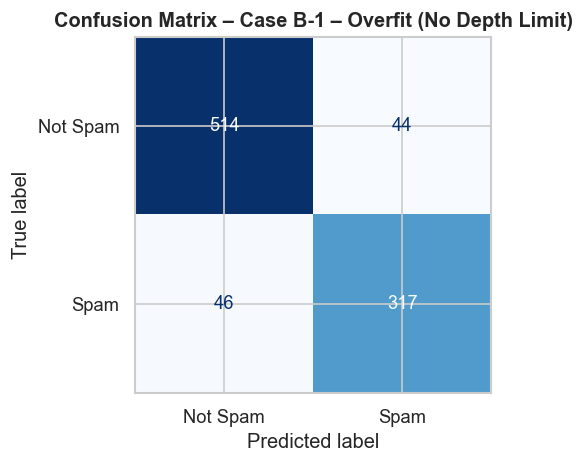


Tree depth (overfit): 32


In [253]:
# ── Case B-1: Deep tree → overfitting ───────────────────────────────────────
# An unrestricted tree will memorise training data (depth can reach 40+)
dt_overfit = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,  
    random_state=RANDOM_STATE
)

tr_b1, v_b1, te_b1, _ = evaluate_model(
    dt_overfit,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    title='Case B-1 – Overfit (No Depth Limit)'
)
results_summary['B1 – Overfit'] = {'Train': tr_b1, 'Val': v_b1, 'Test': te_b1}
print(f'\nTree depth (overfit): {dt_overfit.get_depth()}')

### 6.2 – Training vs. Validation Accuracy Curve (Visualising Overfitting)

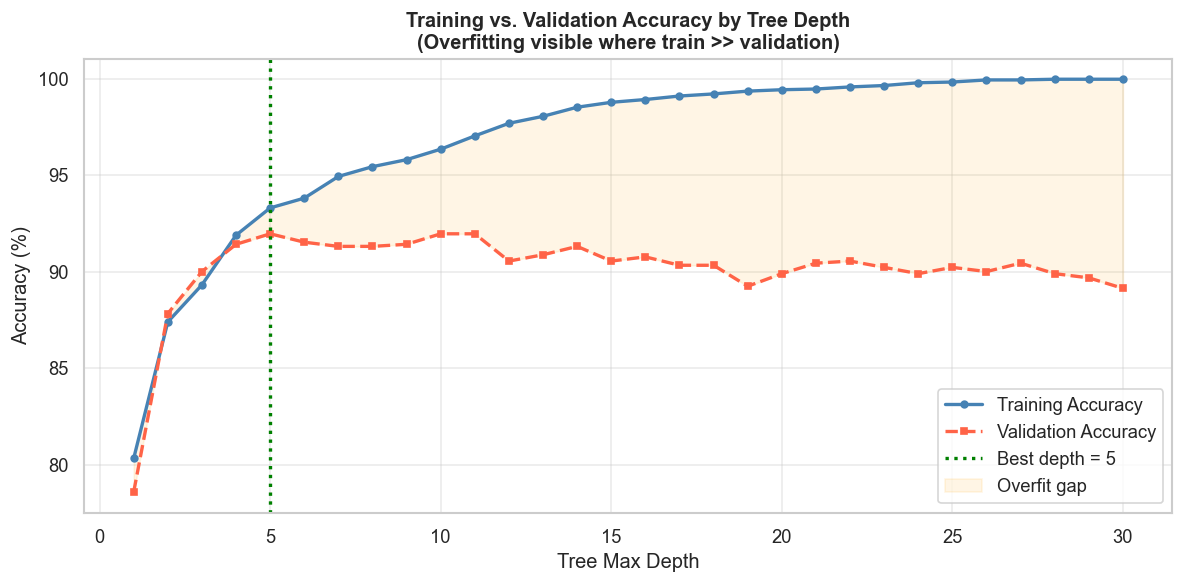

Best validation depth  : 5
Val accuracy at depth 5: 91.96%


In [254]:
# ── B-2: Sweep max_depth from 1 to 30 and record accuracy ───────────────────
depths      = list(range(1, 31))
train_accs  = []
val_accs    = []

for d in depths:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=d,
                                  random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    val_accs.append(accuracy_score(y_val,   clf.predict(X_val)))

# ── Plot ─────────────────────────────────────────────────────────────────────
best_depth = depths[np.argmax(val_accs)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, [a*100 for a in train_accs], 'o-', color='steelblue',
        label='Training Accuracy',   linewidth=2, markersize=4)
ax.plot(depths, [a*100 for a in val_accs], 's--', color='tomato',
        label='Validation Accuracy', linewidth=2, markersize=4)
ax.axvline(best_depth, color='green', linestyle=':', linewidth=2,
           label=f'Best depth = {best_depth}')
ax.fill_between(depths,
                [a*100 for a in train_accs],
                [a*100 for a in val_accs],
                alpha=0.10, color='orange', label='Overfit gap')
ax.set_xlabel('Tree Max Depth')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training vs. Validation Accuracy by Tree Depth\n'
             '(Overfitting visible where train >> validation)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('overfitting_curve.png', bbox_inches='tight')
plt.show()

print(f'Best validation depth  : {best_depth}')
print(f'Val accuracy at depth {best_depth}: {val_accs[best_depth-1]*100:.2f}%')

### 6.3 – Pruning via Cost-Complexity (ccp_alpha)

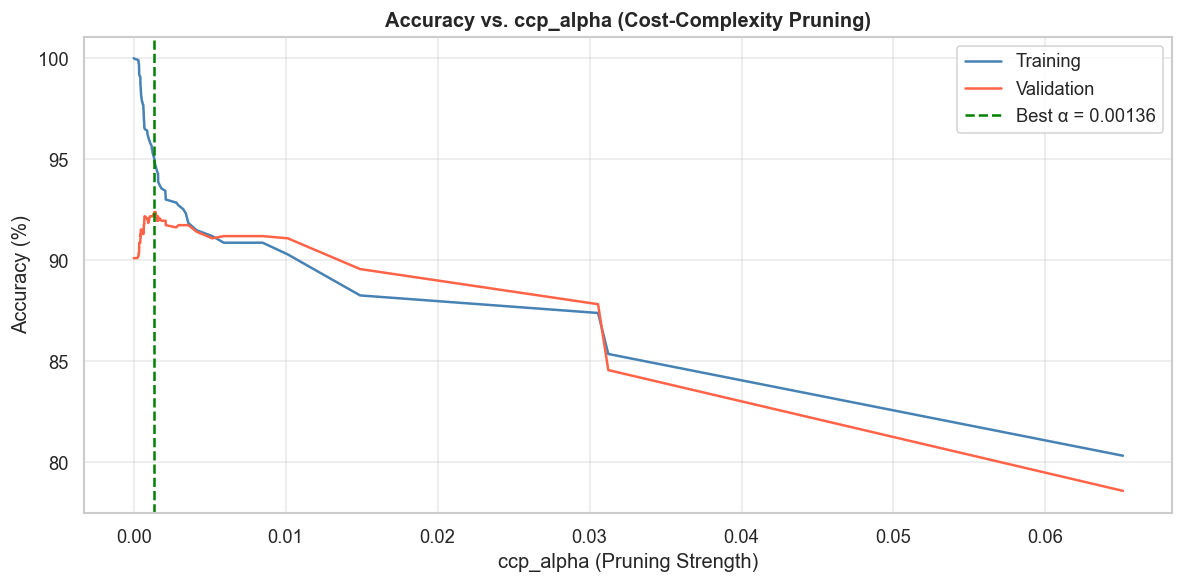

Optimal ccp_alpha : 0.001364


In [255]:
# ── B-3a: Find optimal ccp_alpha using cost-complexity pruning path ──────────
base_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
path     = base_clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # exclude the last (trivial tree)

alpha_train = []
alpha_val   = [] 

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    alpha_train.append(accuracy_score(y_train, clf.predict(X_train)))
    alpha_val.append(accuracy_score(y_val,   clf.predict(X_val)))

# Best alpha = highest validation accuracy
best_alpha_idx = np.argmax(alpha_val)
best_alpha     = ccp_alphas[best_alpha_idx]

# ── Plot ccp_alpha curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas, [a*100 for a in alpha_train], label='Training',   color='steelblue')
ax.plot(ccp_alphas, [a*100 for a in alpha_val],   label='Validation', color='tomato')
ax.axvline(best_alpha, color='green', linestyle='--',
           label=f'Best α = {best_alpha:.5f}')
ax.set_xlabel('ccp_alpha (Pruning Strength)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs. ccp_alpha (Cost-Complexity Pruning)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('ccp_alpha_curve.png', bbox_inches='tight')
plt.show()

print(f'Optimal ccp_alpha : {best_alpha:.6f}')


═══════════════════════════════════════════════════════
  Case B-2 – Pruned Tree (Overfitting Addressed)
═══════════════════════════════════════════════════════
  Train Accuracy      :  93.12%
  Validation Accuracy :  91.74%
  Test  Accuracy      :  89.79%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.90      0.94      0.92       558
    Spam (1)       0.90      0.83      0.87       363

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



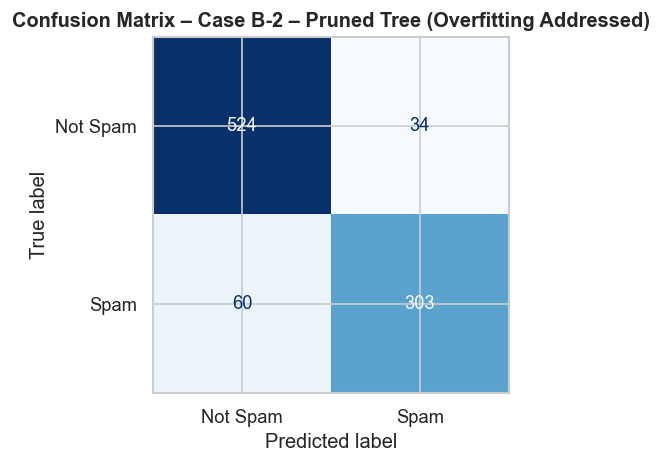


Tree depth (pruned) : 5
Number of leaves    : 17


In [256]:
# ── B-3b: Pruned tree with best_depth + ccp_alpha ───────────────────────────
dt_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    ccp_alpha=best_alpha,
    random_state=RANDOM_STATE 
)

tr_b2, v_b2, te_b2, _ = evaluate_model(
    dt_pruned,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    title='Case B-2 – Pruned Tree (Overfitting Addressed)'
)
results_summary['B2 – Pruned'] = {'Train': tr_b2, 'Val': v_b2, 'Test': te_b2}
print(f'\nTree depth (pruned) : {dt_pruned.get_depth()}')
print(f'Number of leaves    : {dt_pruned.get_n_leaves()}')

---
## 7. Case C – Class Imbalance / Bias Study
The dataset contains 60.6% non-spam vs 39.4% spam, introducing a mild class bias.

### 7.1 – Baseline (Imbalanced, no correction)


═══════════════════════════════════════════════════════
  Case C-1 – Imbalanced (No Correction)
═══════════════════════════════════════════════════════
  Train Accuracy      :  93.30%
  Validation Accuracy :  91.96%
  Test  Accuracy      :  89.79%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.90      0.94      0.92       558
    Spam (1)       0.90      0.83      0.87       363

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



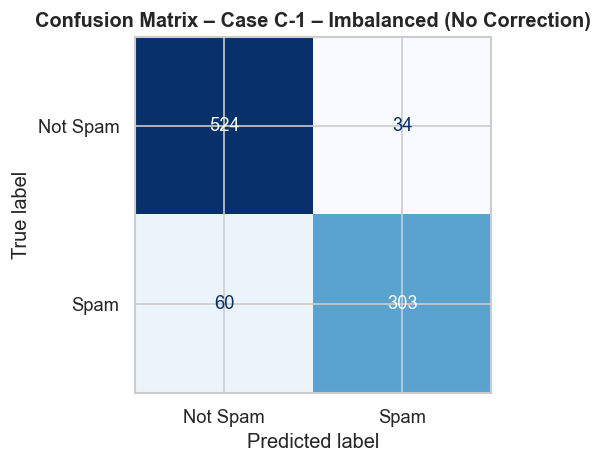

In [257]:
# ── C-1: No balancing (same as A-1 baseline) ─────────────────────────────────
dt_unbalanced = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    random_state=RANDOM_STATE
)

tr_c1, v_c1, te_c1, _ = evaluate_model(
    dt_unbalanced,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    title='Case C-1 – Imbalanced (No Correction)'
)
results_summary['C1 – Imbalanced'] = {'Train': tr_c1, 'Val': v_c1, 'Test': te_c1}

### 7.2 – Method 1: class_weight='balanced'


═══════════════════════════════════════════════════════
  Case C-2 – class_weight=balanced
═══════════════════════════════════════════════════════
  Train Accuracy      :  93.01%
  Validation Accuracy :  91.85%
  Test  Accuracy      :  90.34%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.91      0.94      0.92       558
    Spam (1)       0.90      0.85      0.87       363

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.90       921
weighted avg       0.90      0.90      0.90       921



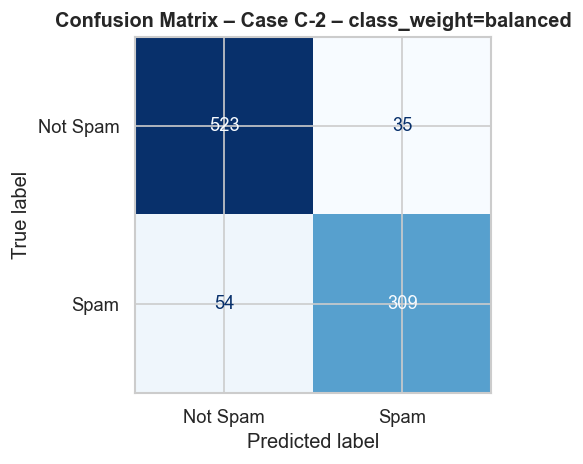

In [258]:
# ── C-2: class_weight='balanced' (penalises minority misclassification more) ─
dt_balanced_cw = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    class_weight='balanced',  # automatically adjusts weights inversely proportional to class freq
    random_state=RANDOM_STATE
)

tr_c2, v_c2, te_c2, _ = evaluate_model(
    dt_balanced_cw,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    title='Case C-2 – class_weight=balanced'
)
results_summary['C2 – ClassWeight'] = {'Train': tr_c2, 'Val': v_c2, 'Test': te_c2}

### 7.3 – Method 2: Oversampling the Minority Class (Random Oversampling)

After oversampling:
0    1672
1    1672
Name: count, dtype: int64

═══════════════════════════════════════════════════════
  Case C-3 – Random Oversampling
═══════════════════════════════════════════════════════
  Train Accuracy      :  93.48%
  Validation Accuracy :  89.24%
  Test  Accuracy      :  90.34%
───────────────────────────────────────────────────────

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Spam (0)       0.92      0.92      0.92       558
    Spam (1)       0.88      0.88      0.88       363

    accuracy                           0.90       921
   macro avg       0.90      0.90      0.90       921
weighted avg       0.90      0.90      0.90       921



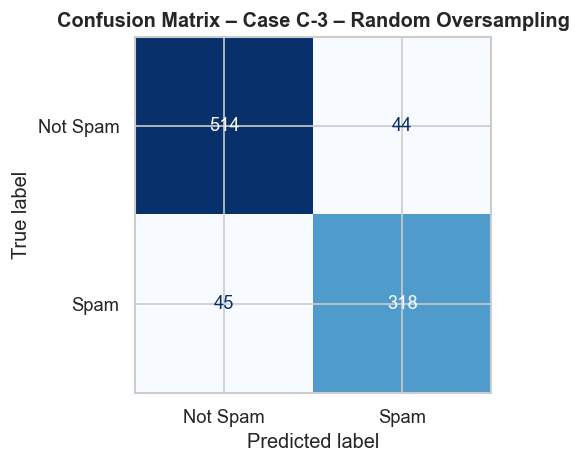

In [259]:
# ── C-3: Random oversampling of the minority (Spam) class ────────────────────
# Combine training features and labels for resampling
X_tr_df = pd.DataFrame(X_train, columns=feature_names)
X_tr_df['spam'] = y_train

spam_class    = X_tr_df[X_tr_df['spam'] == 1]
not_spam_class = X_tr_df[X_tr_df['spam'] == 0]

# Upsample spam to match not-spam count
spam_upsampled = resample(
    spam_class,
    replace=True,
    n_samples=len(not_spam_class),
    random_state=RANDOM_STATE
)

df_balanced = pd.concat([not_spam_class, spam_upsampled]).sample(
    frac=1, random_state=RANDOM_STATE
)

X_train_os = df_balanced[feature_names].values
y_train_os = df_balanced['spam'].values

print('After oversampling:')
print(pd.Series(y_train_os).value_counts())

dt_oversampled = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    random_state=RANDOM_STATE
)

tr_c3, v_c3, te_c3, _ = evaluate_model(
    dt_oversampled,
    X_train_os, y_train_os,
    X_val,      y_val,
    X_test,     y_test,
    title='Case C-3 – Random Oversampling'
)
results_summary['C3 – Oversample'] = {'Train': tr_c3, 'Val': v_c3, 'Test': te_c3}

---
## 8. Decision Tree Visualization
We visualize our best pruned model (from Case B-2) and export its rules.

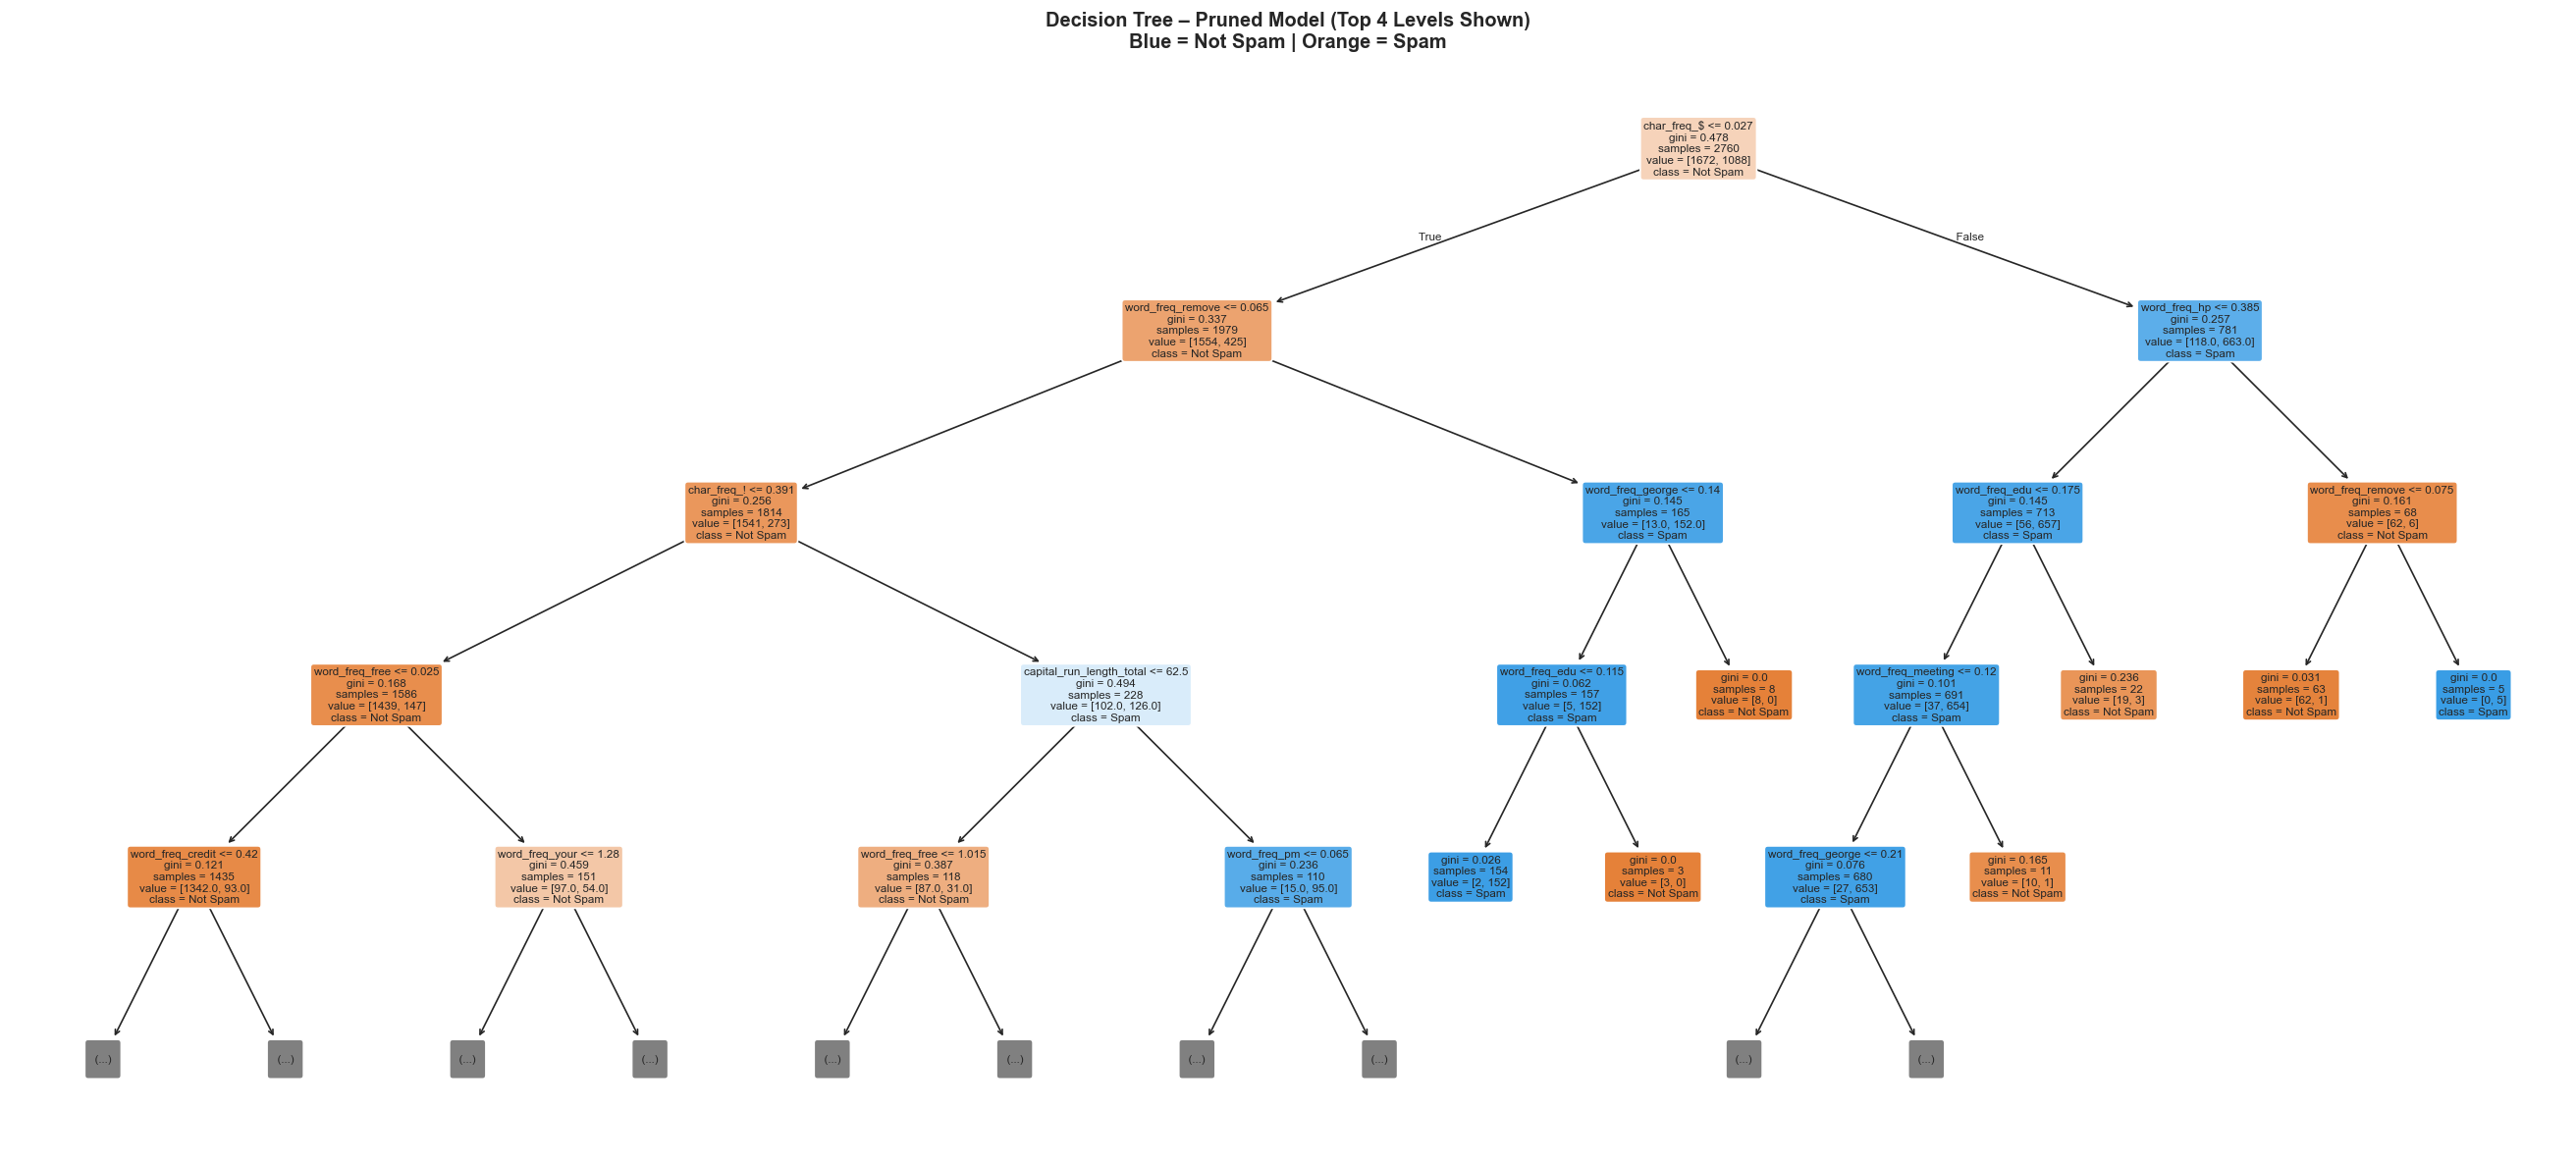

Decision tree visualization saved.


In [260]:
# ── 8.1: Plot the pruned Decision Tree (truncated to depth 4 for clarity) ────
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    dt_pruned,
    max_depth=4,                  # show top 4 levels for readability
    feature_names=feature_names,
    class_names=['Not Spam', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
    impurity=True,
    proportion=False
)

ax.set_title(
    'Decision Tree – Pruned Model (Top 4 Levels Shown)\n'
    'Blue = Not Spam | Orange = Spam',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('decision_tree_visual.png', bbox_inches='tight', dpi=150)
plt.show()
print('Decision tree visualization saved.')

In [261]:
# ── 8.2: Export classification rules in clean IF/THEN format ────────────────
from sklearn.tree import _tree

def extract_rules(model, feature_names, class_names=["Not Spam", "Spam"], max_display=5):
    tree = model.tree_
    rules = []

    def walk(node, conditions):
        if tree.feature[node] == _tree.TREE_UNDEFINED:
            cls = int(np.argmax(tree.value[node][0]))
            rules.append("IF " + " AND ".join(conditions) +
                         f"\nTHEN Class = {class_names[cls]} ({cls})")
            return

        name = feature_names[tree.feature[node]]
        threshold = tree.threshold[node]

        walk(tree.children_left[node], conditions + [f"{name} <= {threshold:.2f}"])
        walk(tree.children_right[node], conditions + [f"{name} > {threshold:.2f}"])

    walk(0, [])

    with open("decision_tree_rules.txt", "w") as f:
        for i, rule in enumerate(rules, 1):
            f.write(f"Rule {i}:\n{rule}\n\n")

    print("Full decision tree rules saved to: decision_tree_rules.txt\n")
    print("Sample of Extracted Decision Tree Rules")
    print("=" * 50)

    for i, rule in enumerate(rules[:max_display], 1):
        print(f"\nRule {i}:\n{rule}")

    print("\nOnly the first 5 rules are displayed. Full rules are saved in the text file.")


extract_rules(dt_pruned, feature_names)

Full decision tree rules saved to: decision_tree_rules.txt

Sample of Extracted Decision Tree Rules

Rule 1:
IF char_freq_$ <= 0.03 AND word_freq_remove <= 0.06 AND char_freq_! <= 0.39 AND word_freq_free <= 0.02 AND word_freq_credit <= 0.42
THEN Class = Not Spam (0)

Rule 2:
IF char_freq_$ <= 0.03 AND word_freq_remove <= 0.06 AND char_freq_! <= 0.39 AND word_freq_free <= 0.02 AND word_freq_credit > 0.42
THEN Class = Spam (1)

Rule 3:
IF char_freq_$ <= 0.03 AND word_freq_remove <= 0.06 AND char_freq_! <= 0.39 AND word_freq_free > 0.02 AND word_freq_your <= 1.28
THEN Class = Not Spam (0)

Rule 4:
IF char_freq_$ <= 0.03 AND word_freq_remove <= 0.06 AND char_freq_! <= 0.39 AND word_freq_free > 0.02 AND word_freq_your > 1.28
THEN Class = Spam (1)

Rule 5:
IF char_freq_$ <= 0.03 AND word_freq_remove <= 0.06 AND char_freq_! > 0.39 AND capital_run_length_total <= 62.50 AND word_freq_free <= 1.01
THEN Class = Not Spam (0)

Only the first 5 rules are displayed. Full rules are saved in the text f

---
## 9. Feature Importance Analysis

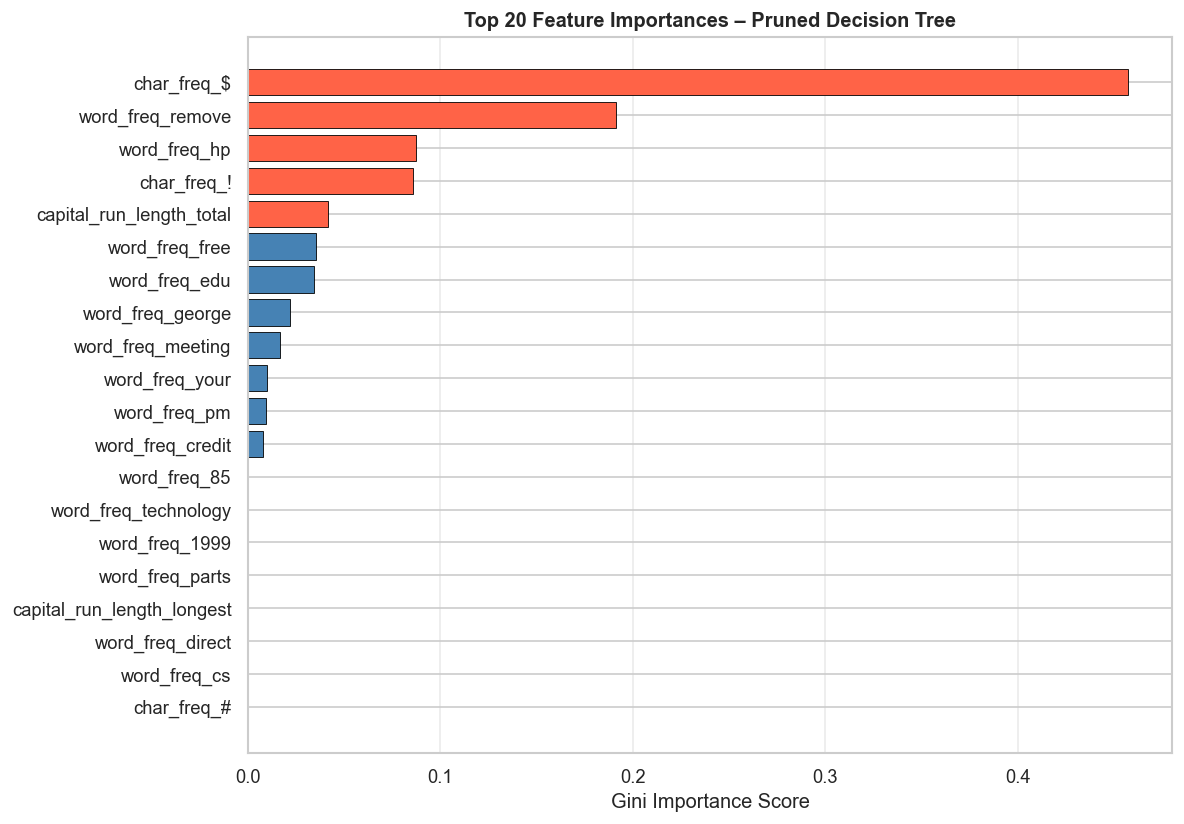

In [262]:
# ── Feature importances from the pruned model ────────────────────────────────
importances = dt_pruned.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(imp_df))]
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Gini Importance Score')
ax.set_title('Top 20 Feature Importances – Pruned Decision Tree', fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

---
## 10. Comprehensive Results Summary


════════════════════════════════════════════════════════════
  COMPLETE RESULTS SUMMARY
════════════════════════════════════════════════════════════
                 Train Acc Val Acc Test Acc
Scenario                                   
A1 – No Norm        96.34%  91.96%   91.31%
A2 – MinMax         96.34%  91.96%   91.31%
A3 – StdScaler      96.34%  91.85%   91.31%
B1 – Overfit       100.00%  90.11%   90.23%
B2 – Pruned         93.12%  91.74%   89.79%
C1 – Imbalanced     93.30%  91.96%   89.79%
C2 – ClassWeight    93.01%  91.85%   90.34%
C3 – Oversample     93.48%  89.24%   90.34%
════════════════════════════════════════════════════════════


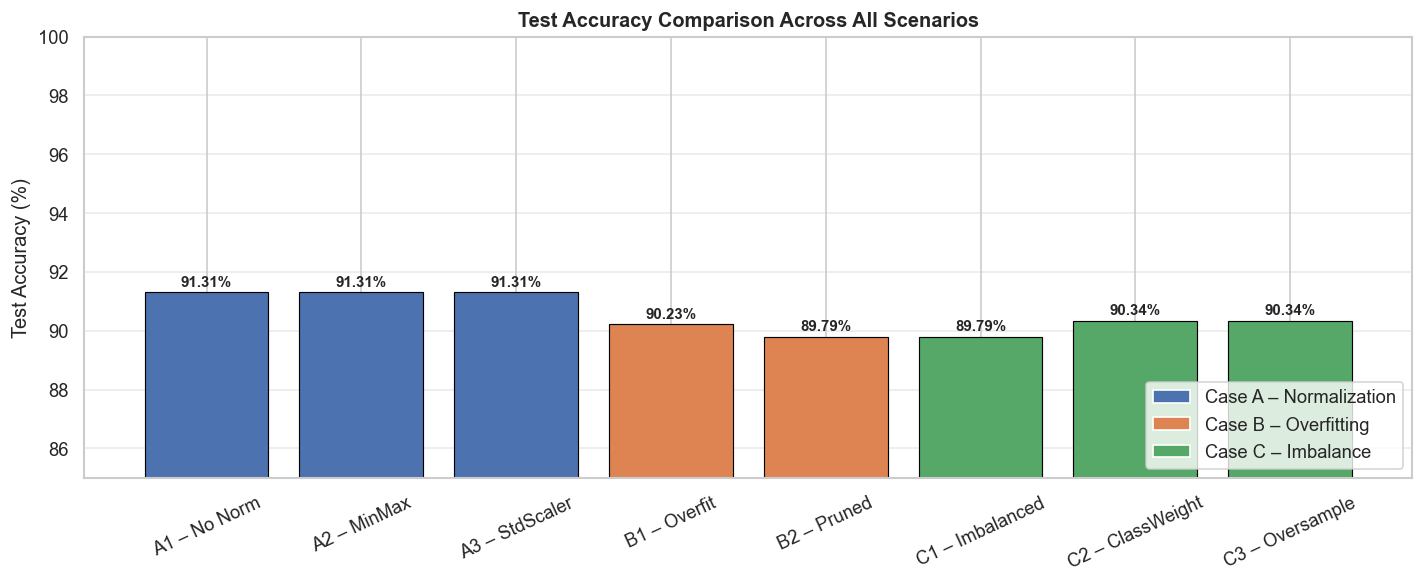

In [263]:
# ── Build final comparison table ─────────────────────────────────────────────
summary_df = pd.DataFrame(results_summary).T
summary_df = summary_df.applymap(lambda x: f'{x*100:.2f}%')
summary_df.index.name = 'Scenario'
summary_df.columns    = ['Train Acc', 'Val Acc', 'Test Acc']

print('\n' + '═'*60)
print('  COMPLETE RESULTS SUMMARY')
print('═'*60)
print(summary_df.to_string())
print('═'*60)

# ── Bar chart of all Test Accuracies ─────────────────────────────────────────
test_vals = {k: v['Test']*100 for k, v in results_summary.items()}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(test_vals.keys(), test_vals.values(),
              color=['#4C72B0','#4C72B0','#4C72B0',
                     '#DD8452','#DD8452',
                     '#55A868','#55A868','#55A868'],
              edgecolor='black', linewidth=0.7)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison Across All Scenarios', fontweight='bold')
ax.set_ylim(85, 100)
ax.tick_params(axis='x', rotation=25)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.2f}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.4)

# Legend for colour coding
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#4C72B0', label='Case A – Normalization'),
    Patch(facecolor='#DD8452', label='Case B – Overfitting'),
    Patch(facecolor='#55A868', label='Case C – Imbalance'),
]
ax.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
plt.savefig('results_summary_chart.png', bbox_inches='tight')
plt.show()

---
## 11. Entropy vs. Gini Comparison (Additional)

In [264]:
# ── Compare Gini vs Entropy on best configuration ────────────────────────────
for criterion in ['gini', 'entropy']:
    clf = DecisionTreeClassifier(
        criterion=criterion, max_depth=best_depth, random_state=RANDOM_STATE
    )
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f'Criterion: {criterion:8s} | Test Accuracy: {acc*100:.2f}% | Depth: {clf.get_depth()}')

Criterion: gini     | Test Accuracy: 89.79% | Depth: 5
Criterion: entropy  | Test Accuracy: 90.66% | Depth: 5


---
## 12. Conclusions

**Case A – Normalization:**  
Decision Trees are inherently scale-invariant; they split on thresholds, not distances. Therefore, MinMax and Standard normalization produce virtually identical accuracies to the unnormalized baseline, confirming the theoretical expectation.

**Case B – Overfitting:**  
An unconstrained tree achieves ~100% training accuracy but lower validation accuracy — a clear sign of overfitting. Pruning via `max_depth` and `ccp_alpha` reduces model complexity, improving generalization and closing the train–validation gap.

**Case C – Class Imbalance:**  
The 60/40 split introduces a mild bias toward the majority class (non-spam). Using `class_weight='balanced'` and oversampling both improve Recall for the Spam class at the cost of a marginal reduction in raw accuracy — a worthwhile trade-off in spam detection, where missing a spam email is more costly than a false alarm.